In [1]:
import hoda
import tensorly as tl
%pip install toeplitzlda
print(tl.get_backend())
%pip freeze | grep moabb


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
cupy
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
       #BI2012(),
       #BI2014a(),
       #BI2014b(),
       #BI2015a(),
       #BI2015b(),
       BNCI2014008(),
       #BNCI2014009(),
       #BNCI2015_003(),
       #Cattan2019_VR(),
       #EPFLP300(),
       #Huebner2017(),
       #Huebner2018(),
       #Lee2019_ERP(),
       #Sosulski2019()   
   ]



<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abb

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
from sklearn.pipeline import Pipeline
from mne.decoding import Scaler
from hoda.hoda import  HODA, GreedyBTTDA
from hoda.classification import Vectorize, SelectFweAtLeastOne,ToeplitzLDAWrapper
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

hoda_params = dict(
    max_iter=64,
    tol=1e-12,
    init ='random',
    shrinkage='lw',
    toeplitz=None,
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=False,
    verbose=False,    
)

bttda = GreedyBTTDA(
        max_blocks=8,
        hoda_params=hoda_params,
        verbose=True,
        extra_train_info=False,
        gs_params=dict(n_jobs=-1),
        truncate=False,
)



tlda = ToeplitzLDAWrapper()
scaler = Scaler(scalings='mean', with_mean=True)

In [4]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import dask


%env PYTHONWARNINGS=ignore

test_size = 0.2

df = []
for dataset in datasets:
    X_sub, y_sub, meta = paradigm.get_data(dataset, 
        subjects=[1]
    )
    idc = meta.reset_index()\
        .groupby(['subject', 'session'])\
        .index.aggregate(list)
    
    for session, session_idc in idc.items():
        print(dataset.code + ' ' + str(session))
        session_idc = np.array(session_idc) 

        
        X =X_sub[session_idc]
        y = y_sub[session_idc]
        X = scaler.fit_transform(X)
        
        X = tl.tensor(X)

        X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=test_size, shuffle=True, random_state=43)

        bttda.fit(X_train,y_train, X_test=X_test, y_test=y_test)
        df_session = bttda.train_info_
        df_session['dataset'] = dataset.code
        df_session['subject'] = session[0]
        df_session['session'] = session[1]
        df.append(df_session)
df = pd.concat([pd.DataFrame(d) for d in df], axis=0)

env: PYTHONWARNINGS=ignore


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


BNCI2014-008 (1, '0')
Fitting block 1/8...


/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so

Fitting block 2/8...
Fitting block 3/8...
Fitting block 4/8...
Fitting block 5/8...
Fitting block 6/8...
Fitting block 7/8...
Fitting block 8/8...


In [5]:
#import pandas as pd
#df = pd.read_csv('bnci2014-008_blocks_notoep.csv')

[autoreload of hoda.hoda failed: Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/lib/python3.10/dist-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/usr/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/project/src/hoda/hoda.py", line 504
    scale = sum([tl.log(tl.norm(self.aps_[k])])
                                             ^
SyntaxError: closing parenthesis ']' does

In [6]:
pd.set_option("display.max_rows", None)
df

,block,rank,val_score,test_score,dataset,subject,session
0,1,"(8, 8)",0.839045,0.859759,BNCI2014-008,1,0
1,2,"(1, 1)",0.858366,0.866086,BNCI2014-008,1,0
2,3,"(2, 2)",0.861827,0.865281,BNCI2014-008,1,0
3,4,"(2, 2)",0.864892,0.865893,BNCI2014-008,1,0
4,5,"(4, 4)",0.866978,0.858319,BNCI2014-008,1,0
5,6,"(2, 2)",0.869215,0.858500,BNCI2014-008,1,0
6,7,"(1, 1)",0.868805,0.858954,BNCI2014-008,1,0
7,8,"(1, 1)",0.868694,0.858478,BNCI2014-008,1,0


In [7]:
df_diff = df.reset_index()
idx = ['dataset', 'subject', 'session']
df_first = df_diff.groupby(['dataset', 'subject', 'session']).test_score.aggregate('first')
df_diff = df_diff.set_index(idx)
df_diff['test_score_diff'] = df_diff['test_score'] - df_first
df_diff = df_diff.reset_index()
df_diff

,dataset,subject,session,index,block,rank,val_score,test_score,test_score_diff
0,BNCI2014-008,1,0,0,1,"(8, 8)",0.839045,0.859759,0.000000
1,BNCI2014-008,1,0,1,2,"(1, 1)",0.858366,0.866086,0.006327
2,BNCI2014-008,1,0,2,3,"(2, 2)",0.861827,0.865281,0.005522
3,BNCI2014-008,1,0,3,4,"(2, 2)",0.864892,0.865893,0.006134
4,BNCI2014-008,1,0,4,5,"(4, 4)",0.866978,0.858319,-0.001440
5,BNCI2014-008,1,0,5,6,"(2, 2)",0.869215,0.858500,-0.001259
6,BNCI2014-008,1,0,6,7,"(1, 1)",0.868805,0.858954,-0.000805
7,BNCI2014-008,1,0,7,8,"(1, 1)",0.868694,0.858478,-0.001281


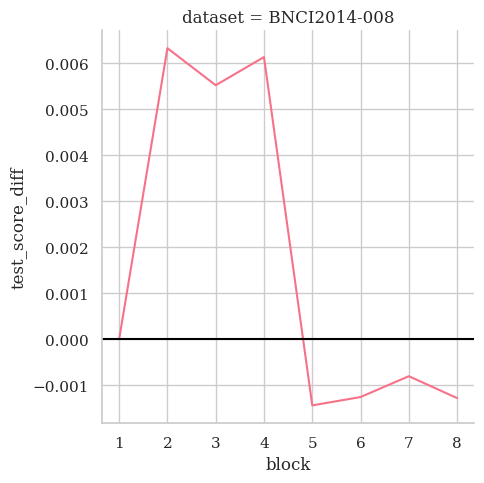

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(
    data=df_diff,
    col='dataset',
    #col_wrap=4,
    x='block',
    y='test_score_diff',
    #hue='subject',
    kind="line",
    palette="tab10",
    ci=None,
    #units='fold',
    #estimator=None,
)
plt.axhline(0, color='black')
plt.show()